<a href="https://colab.research.google.com/github/Gautamkhushboo/Machine-Vision-LAB/blob/main/Machine_Vision_6(25)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub


In [ ]:
import kagglehub

path = kagglehub.dataset_download("msambare/fer2013")

print("Dataset Path:", path)


Using Colab cache for faster access to the 'fer2013' dataset.
Dataset Path: /kaggle/input/fer2013


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print(dirs[:5])
    break


/kaggle/input/fer2013
['test', 'train']


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
train_dir = path + "/train"
test_dir = path + "/test"


In [ ]:
classes = [
    "happy",
    "sad",
    "neutral",
    "surprise"
]


In [ ]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    class_names=classes,
    color_mode="grayscale",
    image_size=(48,48),
    batch_size=32
)


test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    class_names=classes,
    color_mode="grayscale",
    image_size=(48,48),
    batch_size=32
)


Found 20181 files belonging to 4 classes.
Found 5085 files belonging to 4 classes.


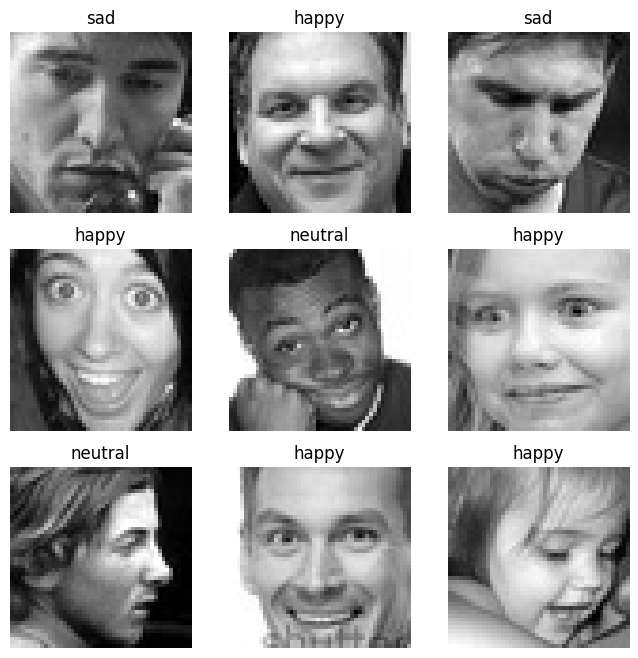

In [ ]:
plt.figure(figsize=(8,8))

for images, labels in train_data.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8").squeeze(),
                   cmap="gray")

        plt.title(classes[labels[i]])

        plt.axis("off")


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(48,48,3),
    include_top=False,
    weights=None
)


In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )

])


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=4
)


Epoch 1/4
631/631 ━━━━━━━━━━━━━━━━━━━━ 82s 131ms/step - accuracy: 0.5631 - loss: 1.0245 - val_accuracy: 0.6077 - val_loss: 0.9364
Epoch 2/4
631/631 ━━━━━━━━━━━━━━━━━━━━ 76s 120ms/step - accuracy: 0.6300 - loss: 0.8889 - val_accuracy: 0.6208 - val_loss: 0.8912
Epoch 3/4
631/631 ━━━━━━━━━━━━━━━━━━━━ 78s 114ms/step - accuracy: 0.6676 - loss: 0.8103 - val_accuracy: 0.6456 - val_loss: 0.8354
Epoch 4/4
631/631 ━━━━━━━━━━━━━━━━━━━━ 71s 113ms/step - accuracy: 0.7004 - loss: 0.7376 - val_accuracy: 0.6521 - val_loss: 0.8262


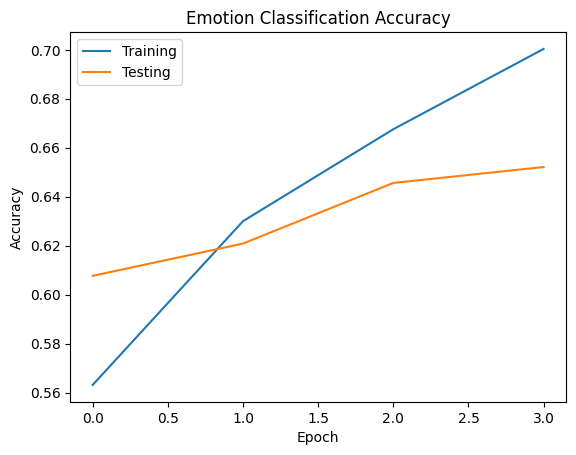

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Emotion Classification Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Training","Testing"])

plt.show()


In [ ]:
for images, labels in test_data.take(1):

    prediction = model.predict(images)

    index = np.argmax(prediction[0])

    print(
        "Predicted Emotion:",
        classes[index]
    )

    print(
        "Actual Emotion:",
        classes[labels[0]]
    )


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Predicted Emotion: happy
Actual Emotion: happy


In [ ]:
model.save("customer_emotion_model.h5")
